In [77]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
import matplotlib as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import branca.colormap as cm
import h3
import srai  # Spatial Representations for Artificial Intelligence

#import both data sets for traning (here is Hokkaido region)
#import both datasets with AHP_SCORE AND SPP_PRESENCE
socio_env = gpd.read_file ("/Users/eliviau/Documents/hex2vec/SSPpresenceandscoresocioenvhokkaido3.geojson")
techno_econ = gpd.read_file ("/Users/eliviau/Documents/hex2vec/SSPpresenceandscorestechnohokkaidoFINAL.geojson")


In [78]:
socio_env.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,is_protected,SPP_presence,geometry
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,0,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973..."
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,0,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545..."
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,0,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688..."
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,1,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142..."
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,0,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914..."


In [79]:
techno_econ.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,SPP_presence,geometry
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,0,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,0,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,0,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,0,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,0,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


In [80]:
# rename ahp_total_score to ahp_total_score_socioenv
socio_env = socio_env.rename(columns={'ahp_total_score': 'ahp_total_score_socioenv'})
# rename ahp_total_score to ahp_total_score_technoecon
techno_econ = techno_econ.rename(columns={'ahp_total_score': 'ahp_total_score_technoecon'})
# 1. Make copies to avoid modifying originals
tech_df = techno_econ.copy()
socio_df = socio_env.copy()  


In [81]:
#merge combined_gdf with spp_data
power_plants = gpd.read_file("/Users/eliviau/Documents/hex2vec/power_plants_hokkaido.geojson")  

In [52]:
#merge tech_df with spp_data with socio_df
combined_gdf = tech_df.merge(
    socio_df[['region_id', 'geometry', 'ahp_total_score_socioenv']], 
    on='region_id', 
    how='left', 
    suffixes=('_technoecon', '_socioenv')
)

In [53]:
combined_df

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score_technoecon,SPP_presence,geometry,ahp_total_score_socioenv
0,872e0a699ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.27153 41.35064, 140.26731 41.362...",3.25
1,872e0a69affffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.30421 41.37854, 140.29999 41.390...",NaN
2,872e0a69bffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.2782 41.37213, 140.27398 41.3843...",3.25
3,872e0a6c3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.12853 41.27558, 140.12429 41.287...",NaN
4,872e0a6c8ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.07674 41.26272, 140.07251 41.274...",NaN
...,...,...,...,...,...,...,...,...,...,...
31783,872ef6db2ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((142.73525 45.05853, 142.73114 45.070...",NaN
31784,872ef6db3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((142.70683 45.05216, 142.70272 45.064...",NaN
31785,872ef6db4ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((142.74757 45.02188, 142.74347 45.034...",NaN
31786,872ef6db5ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((142.71917 45.01551, 142.71506 45.027...",NaN


In [62]:
    # 2. Merge on region_id, which is the actual H3 index column
combined_df = tech_df.merge(
        socio_df[['region_id', 'ahp_total_score_socioenv']], 
        on='region_id',
        how='outer',  # Use outer join to keep all hexagons
        suffixes=('', '_tech')
    )
    


In [44]:
combined_df.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score_technoecon,SPP_presence,geometry,ahp_total_score_socioenv
0,872e0a699ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.27153 41.35064, 140.26731 41.362...",3.25
1,872e0a69affffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.30421 41.37854, 140.29999 41.390...",NaN
2,872e0a69bffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.2782 41.37213, 140.27398 41.3843...",3.25
3,872e0a6c3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.12853 41.27558, 140.12429 41.287...",NaN
4,872e0a6c8ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.07674 41.26272, 140.07251 41.274...",NaN


In [63]:
    # 4. Convert back to GeoDataFrame
combined_gdf = gpd.GeoDataFrame(combined_df, geometry='geometry', crs=tech_df.crs)


In [46]:
#merge combined_gdf with spp_data
spp_data = gpd.read_file("/Users/eliviau/Documents/hex2vec/power_plants_hokkaido.geojson")  
# Merge with spp_data
combined_df = combined_gdf.merge(
    spp_data[['region_id', 'geometry']], 
    on='region_id',
    how='left',
    suffixes=('', '_spp')
)

KeyError: "['region_id'] not in index"

In [64]:
#create new score column combined with ahp_total_score_technoecon and ahp_total_score_socioenv

# Define threshold
threshold = 5

# Function to classify each row
def classify_typology(row):
    tech = row['ahp_total_score_technoecon']
    socio = row['ahp_total_score_socioenv']
    
    if tech >= threshold and socio >= threshold:
        return 'Ideal'
    elif tech >= threshold and socio < threshold:
        return 'Conflict A (Profit vs Planet)'
    elif tech < threshold and socio >= threshold:
        return 'Conflict B (Ecology over Economy)'
    else:
        return 'Avoid'

# Apply classification
combined_df['suitability_typology'] = combined_df.apply(classify_typology, axis=1)


In [65]:
import numpy as np

# Define threshold
threshold = 5

# Function to classify each row
def classify_typology(row):
    tech = row['ahp_total_score_technoecon']
    socio = row['ahp_total_score_socioenv']
    
    # If either score is missing, return NaN
    if pd.isna(tech) or pd.isna(socio):
        return np.nan

    # Apply classification rules
    if tech >= threshold and socio >= threshold:
        return 4
    elif tech >= threshold and socio < threshold:
        return 3
    elif tech < threshold and socio >= threshold:
        return 2
    else:
        return 1

# Apply classification
combined_df['suitability_typologynum'] = combined_df.apply(classify_typology, axis=1)


In [66]:
combined_df.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score_technoecon,SPP_presence,geometry,ahp_total_score_socioenv,suitability_typology,suitability_typologynum
0,872e0a699ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.27153 41.35064, 140.26731 41.362...",3.25,Avoid,NaN
1,872e0a69affffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.30421 41.37854, 140.29999 41.390...",NaN,Avoid,NaN
2,872e0a69bffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.2782 41.37213, 140.27398 41.3843...",3.25,Avoid,NaN
3,872e0a6c3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.12853 41.27558, 140.12429 41.287...",NaN,Avoid,NaN
4,872e0a6c8ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.07674 41.26272, 140.07251 41.274...",NaN,Avoid,NaN


In [24]:
#COUNT the number of hexagons in each typology
typology_counts = combined_df['suitability_typology'].value_counts()

In [25]:
typology_counts.head()

suitability_typology
Avoid                                24703
Conflict A (Profit vs Planet)         3945
Ideal                                 1795
Conflict B (Ecology over Economy)     1345
Name: count, dtype: int64

In [ ]:

combined_df = combined_df.set_index("region_id")  

In [72]:
#merge columns :biodiversity_score	landcover_score	sediment_score	 from socio_env to combined_df
combined_df = combined_df.merge(
    socio_env[['region_id', 'biodiversity_score', 'landcover_score', 'sediment_score']], 
    on='region_id',
    how='left',
    suffixes=('', '_socioenv')
)   

In [73]:
combined_df.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score_technoecon,SPP_presence,geometry,ahp_total_score_socioenv,suitability_typology,suitability_typologynum,color,label,biodiversity_score,landcover_score_socioenv,sediment_score
0,872e0a699ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.27153 41.35064, 140.26731 41.362...",3.25,Avoid,NaN,NaN,NaN,5.0,0.0,10.0
1,872e0a69affffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.30421 41.37854, 140.29999 41.390...",NaN,Avoid,NaN,NaN,NaN,NaN,0.0,10.0
2,872e0a69bffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.2782 41.37213, 140.27398 41.3843...",3.25,Avoid,NaN,NaN,NaN,5.0,0.0,10.0
3,872e0a6c3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.12853 41.27558, 140.12429 41.287...",NaN,Avoid,NaN,NaN,NaN,NaN,0.0,10.0
4,872e0a6c8ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.07674 41.26272, 140.07251 41.274...",NaN,Avoid,NaN,NaN,NaN,NaN,0.0,10.0


In [75]:
import geopandas as gpd
import folium



# Step 1: Define your custom colors
category_colors = {
    4: "#2ca25f",  # Green - Ideal
    3: "#feb24c",  # Orange - Conflict A (Profit vs Planet)
    2: "#3182bd",  # Blue - Conflict B (Ecology over Economy)
    1: "#f03b20",  # Red - Avoid
}

# Step 2: Assign color and label columns
category_labels = {
    4: "Ideal",
    3: "Conflict A (Profit vs Planet)",
    2: "Conflict B (Ecology over Economy)",
    1: "Avoid"
}

combined_df["color"] = combined_df["suitability_typologynum"].map(category_colors)
combined_df["label"] = combined_df["suitability_typologynum"].map(category_labels)

# Step 3: Create folium map centered on geometry
center = combined_df.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=7, tiles='cartodbpositron')

# Step 4: Add each polygon with hover tooltip
for _, row in combined_df.iterrows():
    feature = {
        "type": "Feature",
        "geometry": row["geometry"].__geo_interface__,
        "properties": {
            "color": row["color"],
            "label": row["label"]
        }
    }

    # Safely format each score (or show 'N/A' if missing)
    def format_val(val):
        return f"{val:.2f}" if pd.notnull(val) else "N/A"

    tooltip_html = f"""
    <div style="padding: 6px 8px; border-radius: 5px; background-color: white; border: 1px solid #ccc;">
        <b>Typology:</b> {row['label']}<br>
        <b>Techno-Econ Score:</b> {format_val(row['ahp_total_score_technoecon'])}<br>
        <b>Socio-Env Score:</b> {format_val(row['ahp_total_score_socioenv'])}<br>
        <b>Slope:</b> {format_val(row['slope_score'])}<br>
        <b>Aspect:</b> {format_val(row['aspect_score'])}<br>
        <b>Solar:</b> {format_val(row['ahp_solar_score'])}<br>
        <b>Landcover:</b> {format_val(row['landcover_score'])}<br>
        <b>Road:</b> {format_val(row['road_score'])}<br>
        <b>Biodiversity:</b> {format_val(row['biodiversity_score'])}<br>
        <b>Land Cover (Env):</b> {format_val(row['landcover_score_socioenv'])}<br>
        <b>Sediment Risks:</b> {format_val(row['sediment_score'])}
    </div>
    """

    folium.GeoJson(
        feature,
        style_function=lambda feature: {
            "fillColor": feature["properties"]["color"],
            "color": "none",
            "weight": 0.2,
            "fillOpacity": 1,
        },
        tooltip=folium.Tooltip(tooltip_html, sticky=True)
    ).add_to(m)

# Step 5: Add power plants
# ----------- CATEGORIZE SIZE -----------

# Step 5.1: Create size category for power plants
def classify_size(power):
    if power < 10:
        return "small"
    elif 10 <= power < 50:
        return "medium"
    else:
        return "large"

power_plants["size_category"] = power_plants["power"].apply(classify_size)
size_mapping = {"small": 6, "medium": 12, "large": 20}
power_plants["radius_px"] = power_plants["size_category"].map(size_mapping)


# ----------- ADD BLACK POWER PLANTS -----------

for _, row in power_plants.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row["radius_px"],
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(tooltip_text),
    ).add_to(m)


# Step 6: Add a custom legend
legend_html = """
<div style="
    position: fixed; 
    bottom: 40px; left: 40px; width: 270px; height: 135px; 
    border:2px solid grey; z-index:9999; font-size:12px;
    background-color:white;
    padding: 8px;
">
<b>Suitability Legend</b><br>
<span style="background-color:#2ca25f;width:15px;height:15px;display:inline-block;margin-right:5px;"></span> Ideal<br>
<span style="background-color:#feb24c;width:15px;height:15px;display:inline-block;margin-right:5px;"></span> Conflict A (Profit vs Planet)<br>
<span style="background-color:#3182bd;width:15px;height:15px;display:inline-block;margin-right:5px;"></span> Conflict B (Ecology over Economy)<br>
<span style="background-color:#f03b20;width:15px;height:15px;display:inline-block;margin-right:5px;"></span> Avoid
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Step 7: Save map
m.save("combinedtest_custom_colors_with_legend.html")



/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_86322/2707634694.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = combined_df.geometry.centroid.unary_union.centroid
/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_86322/2707634694.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = combined_df.geometry.centroid.unary_union.centroid


/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_86322/2025543190.py:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Suitability Typology")
/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_86322/2025543190.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Suitability Typology")


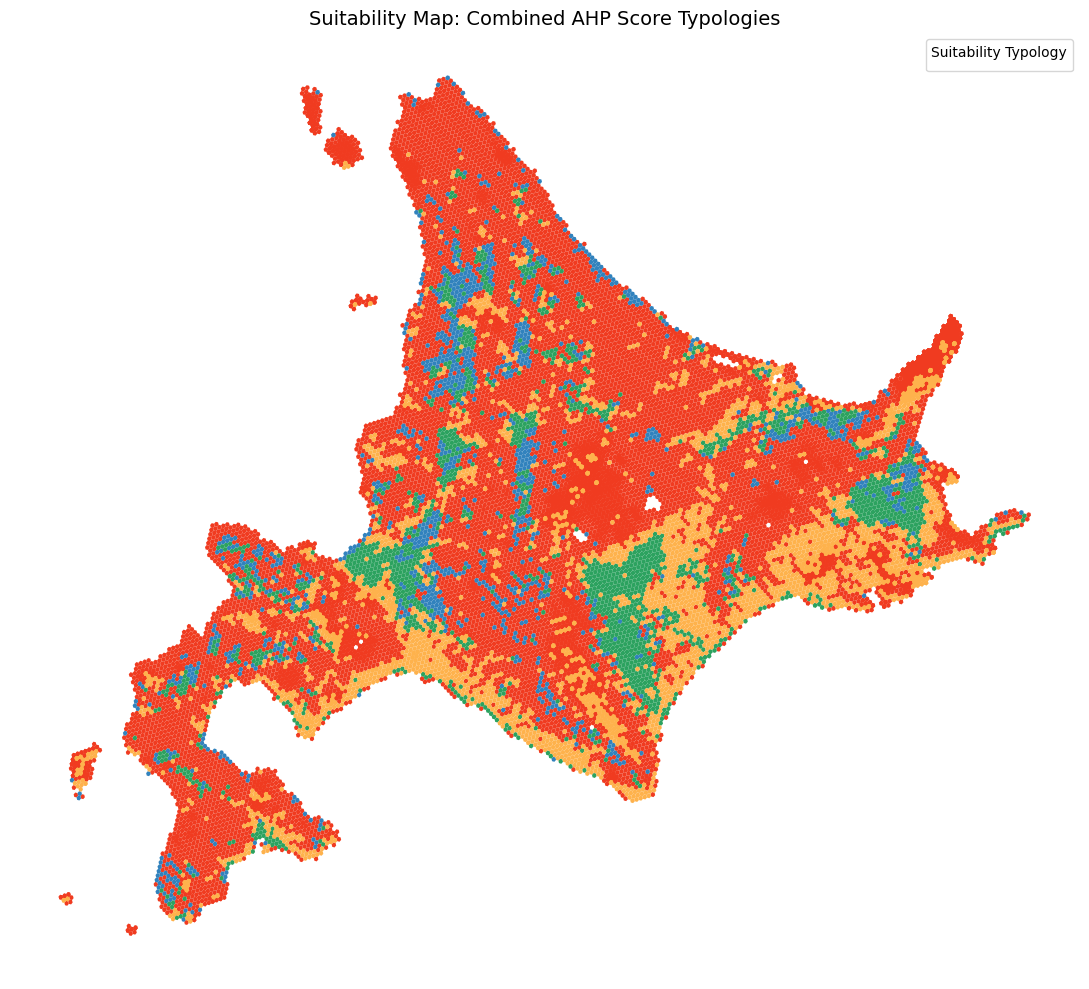

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Step 1: Define your typology color mapping
typology_colors = {
    4: "#2ca25f",  # Ideal - Green
    3: "#feb24c",  # Moderate - Orange
    2: "#3182bd",  # Consider - Blue
    1: "#f03b20",  # Avoid - Red
}
typology_labels = {
    4: "Ideal",
    3: "Moderate",
    2: "Consider",
    1: "Avoid"
}

# Step 2: Assign color and label column if not already present
combined_df["color"] = combined_df["suitability_typologynum"].map(typology_colors)
combined_df["label"] = combined_df["suitability_typologynum"].map(typology_labels)

# Step 3: Plot static map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot hexagons
for typology, group in combined_df.groupby("label"):
    group.plot(ax=ax, color=group["color"].iloc[0], label=typology, linewidth=0)


# Legend & layout
ax.legend(title="Suitability Typology")
ax.set_title("Suitability Map: Combined AHP Score Typologies", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [70]:
print(type(merged_data))                 # should be GeoDataFrame
print(merged_data.geometry.name)         # should be 'geometry_socio'
print(merged_data.geometry.head())       # should print actual shapely geometries


<class 'geopandas.geodataframe.GeoDataFrame'>
geometry_socio
0    POLYGON ((141.77841 42.96173, 141.77429 42.973...
1    POLYGON ((141.92596 45.54248, 141.9217 45.5545...
2    POLYGON ((144.89233 43.67554, 144.88862 43.688...
3    POLYGON ((143.11584 42.12956, 143.11196 42.142...
4    POLYGON ((140.17834 41.90276, 140.17407 41.914...
Name: geometry_socio, dtype: geometry


In [68]:
# Define threshold
threshold = 5

# Function to classify each row
def classify_typology(row):
    tech = row['ahp_total_score_techno']
    socio = row['ahp_total_score_socio']
    
    if tech >= threshold and socio >= threshold:
        return 'Ideal'
    elif tech >= threshold and socio < threshold:
        return 'Conflict A (Profit vs Planet)'
    elif tech < threshold and socio >= threshold:
        return 'Conflict B (Ecology over Economy)'
    else:
        return 'Avoid'

# Apply classification
merged_data['suitability_typology'] = merged_data.apply(classify_typology, axis=1)


In [71]:
import folium
from folium import GeoJson, GeoJsonTooltip

# Ensure geometry is correctly set
merged_data = merged_data.set_geometry('geometry_socio')

# Define your colors for each category
category_colors = {
    "Ideal": "#2ca25f",  # Green
    "Avoid": "#f03b20",  # Red
    "Conflict A (Economy over Ecology)": "#feb24c",  # Orange
    "Conflict B (Ecology over Economy)": "#3182bd",  # Blue
}

# Style function for folium polygons
def style_function(feature):
    typology = feature['properties']['suitability_typology']
    return {
        'fillColor': category_colors.get(typology, 'gray'),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7
    }

# Center map on your hexagon centroid
center = merged_data.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=7, tiles='cartodbpositron')

# Add hexagons
GeoJson(
    merged_data,
    style_function=style_function,
    tooltip=GeoJsonTooltip(fields=['suitability_typology'], aliases=['Type:']),
).add_to(m)

# Add legend
legend_html = """
<div style="position: fixed; 
     bottom: 30px; left: 30px; width: 250px; height: 130px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color: white; padding: 10px;">
<b>Suitability Typology</b><br>
<span style="background-color:#2ca25f;">&nbsp;&nbsp;&nbsp;</span> Ideal<br>
<span style="background-color:#f03b20;">&nbsp;&nbsp;&nbsp;</span> Avoid<br>
<span style="background-color:#feb24c;">&nbsp;&nbsp;&nbsp;</span> Conflict A<br>
<span style="background-color:#3182bd;">&nbsp;&nbsp;&nbsp;</span> Conflict B<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Show map
m


/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_69305/3685417192.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = merged_data.geometry.unary_union.centroid


TypeError: Object of type Polygon is not JSON serializable

In [73]:
import folium

# Set the geometry again just to be sure
merged_data = merged_data.set_geometry('geometry_socio')

# Category colors
category_colors = {
    "Ideal": "#2ca25f",
    "Avoid": "#f03b20",
    "Conflict A (Economy over Ecology)": "#feb24c",
    "Conflict B (Ecology over Economy)": "#3182bd",
}

# Style function
def style_function(feature):
    typology = feature['properties']['suitability_typology']
    return {
        'fillColor': category_colors.get(typology, 'gray'),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7
    }

# Center
center = merged_data.geometry.unary_union().centroid
m = folium.Map(location=[center.y, center.x], zoom_start=7, tiles='cartodbpositron')

# ✅ Use folium.GeoJson (not just GeoJson)
folium.GeoJson(
    merged_data,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['suitability_typology'], aliases=['Type:']),
).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; height: 130px;
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white; padding: 10px;">
<b>Suitability Typology</b><br>
<span style="background-color:#2ca25f;">&nbsp;&nbsp;&nbsp;</span> Ideal<br>
<span style="background-color:#f03b20;">&nbsp;&nbsp;&nbsp;</span> Avoid<br>
<span style="background-color:#feb24c;">&nbsp;&nbsp;&nbsp;</span> Conflict A<br>
<span style="background-color:#3182bd;">&nbsp;&nbsp;&nbsp;</span> Conflict B<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m


/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_69305/1120436990.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = merged_data.geometry.unary_union().centroid


TypeError: 'Polygon' object is not callable

In [72]:
print(merged_data.geometry.name)
print(merged_data.geometry.head())
print(type(merged_data.geometry.iloc[0]))


geometry_socio
0    POLYGON ((141.77841 42.96173, 141.77429 42.973...
1    POLYGON ((141.92596 45.54248, 141.9217 45.5545...
2    POLYGON ((144.89233 43.67554, 144.88862 43.688...
3    POLYGON ((143.11584 42.12956, 143.11196 42.142...
4    POLYGON ((140.17834 41.90276, 140.17407 41.914...
Name: geometry_socio, dtype: geometry
<class 'shapely.geometry.polygon.Polygon'>


In [69]:
merged_data.head()

,region_id,biodiversity_score,landcover_score_socio,sediment_score,ahp_total_score_socio,is_protected,SPP_presence_socio,geometry_socio,slope_score,aspect_score,ahp_solar_score,landcover_score_techno,road_score,ahp_total_score_techno,SPP_presence_techno,geometry_techno,suitability_typology
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,0,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",9.333333,1.812500,9.000000,4.545455,1.608776,4.806089,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",Conflict B (Ecology over Economy)
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,0,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0.000000,0.500000,NaN,4.000000,0.000000,NaN,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",Avoid
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,0,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",6.000000,5.230769,8.846154,8.533333,0.000000,5.427077,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",Ideal
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,1,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",8.166667,1.066667,9.000000,4.600000,0.000000,4.280000,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",Avoid
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,0,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",9.272727,0.000000,5.000000,5.380952,1.105167,4.087723,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",Avoid


/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_69305/4037720569.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


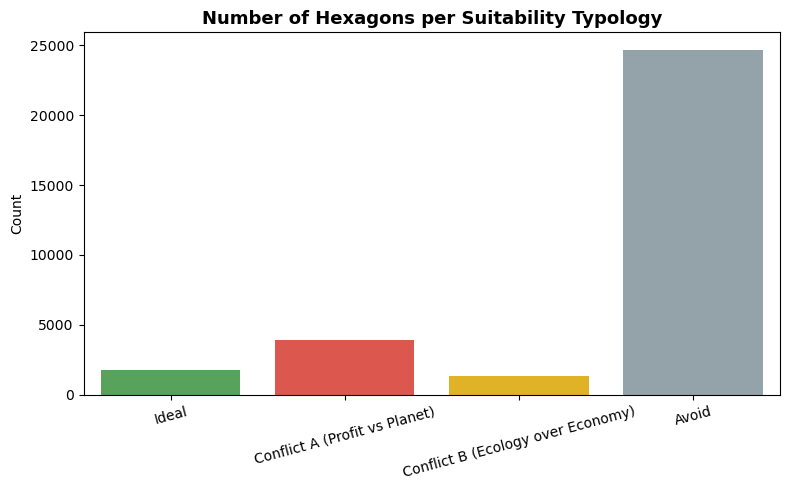

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

custom_palette = {
    'Ideal': '#4CAF50',
    'Conflict A (Profit vs Planet)': '#F44336',
    'Conflict B (Ecology over Economy)': '#FFC107',
    'Avoid': '#90A4AE'
}

plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_data,
    x='suitability_typology',
    order=['Ideal', 'Conflict A (Profit vs Planet)', 'Conflict B (Ecology over Economy)', 'Avoid'],
    palette=custom_palette
)
plt.title('Number of Hexagons per Suitability Typology', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('')  # remove x-axis label for cleaner look
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


ADD the locations of SPP for selected region

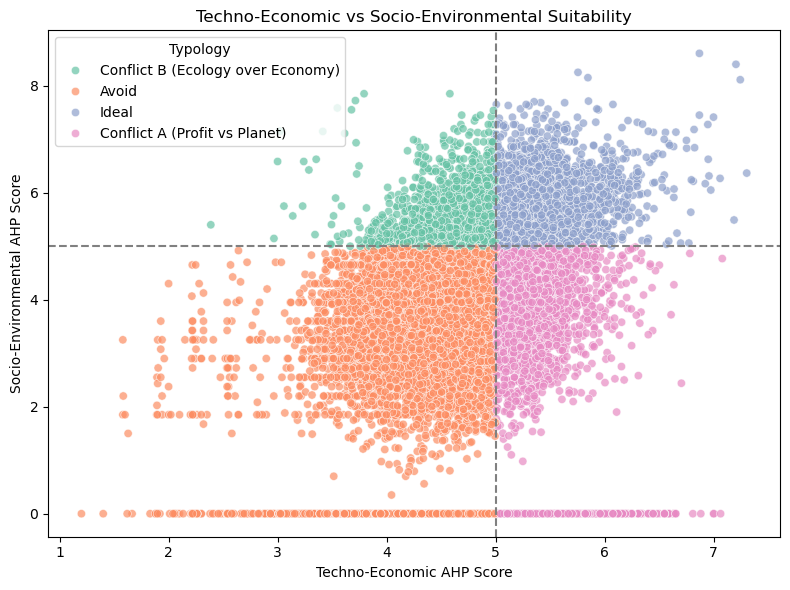

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged_data, 
                x='ahp_total_score_techno', 
                y='ahp_total_score_socio', 
                hue='suitability_typology',
                palette='Set2', alpha=0.7)

# Add threshold lines
plt.axhline(y=5, color='gray', linestyle='--')
plt.axvline(x=5, color='gray', linestyle='--')

plt.title('Techno-Economic vs Socio-Environmental Suitability')
plt.xlabel('Techno-Economic AHP Score')
plt.ylabel('Socio-Environmental AHP Score')
plt.legend(title='Typology')
plt.tight_layout()
plt.show()


In [26]:
spp_data = gpd.read_file("/Users/eliviau/Documents/hex2vec/power_plants_hokkaido.geojson")

In [38]:
#merge spp_Data with socio_env and techno_econ
merged_data = combined_df.merge(
    spp_data[['region_id', 'geometry']], 
    on='region_id', 
    how='left', 
    suffixes=('', '_spp'))

KeyError: "['region_id'] not in index"

In [56]:
combined_df.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score_technoecon,SPP_presence,geometry,ahp_total_score_socioenv
0,872e0a699ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.27153 41.35064, 140.26731 41.362...",3.25
1,872e0a69affffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.30421 41.37854, 140.29999 41.390...",NaN
2,872e0a69bffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.2782 41.37213, 140.27398 41.3843...",3.25
3,872e0a6c3ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.12853 41.27558, 140.12429 41.287...",NaN
4,872e0a6c8ffffff,0.0,1.0,NaN,4.0,0.0,NaN,0,"POLYGON ((140.07674 41.26272, 140.07251 41.274...",NaN


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

custom_palette = {
    'Ideal': '#4CAF50',
    'Conflict A (Profit vs Planet)': '#F44336',
    'Conflict B (Ecology over Economy)': '#FFC107',
    'Avoid': '#90A4AE'
}

plt.figure(figsize=(10, 7))  # Enlarged plot

sns.scatterplot(
    data=combined_df,
    x='ahp_total_score_technoecon',
    y='ahp_total_score_socioenv',
    hue='suitability_typology',
    palette=custom_palette,
    alpha=0.9,
    s=60,
    edgecolor='black',
    legend=False
)

# Threshold lines
plt.axhline(y=5, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=5, color='gray', linestyle='--', linewidth=1)

# Add quadrant annotations, slightly pushed outward
plt.text(6.95, 7.4, 'Ideal', color='#4CAF50', fontsize=12, weight='bold',
         ha='right', va='top')

plt.text(6.95, 0.3, 'Conflict A\n(Profit vs Planet)', color='#F44336', fontsize=11, weight='bold',
         ha='right', va='bottom')

plt.text(3.95, 0.3, 'Avoid', color='#90A4AE', fontsize=12, weight='bold',
         ha='left', va='bottom')

plt.text(3.95, 7.4, 'Economic Trade-Off', color='#FFC107', fontsize=11, weight='bold',
         ha='left', va='top')

# Set axis limits manually for breathing space
plt.xlim(3.5, 7.5)
plt.ylim(-0.5, 8.5)

# Axis and title
plt.title('Classification of Solar Installations by Suitability Conflicts in Hokkaido', fontsize=14, fontweight='bold')
plt.xlabel('Techno-Economic AHP Score', fontsize=12)
plt.ylabel('Socio-Environmental AHP Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `ahp_total_score_techno` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x700 with 0 Axes>

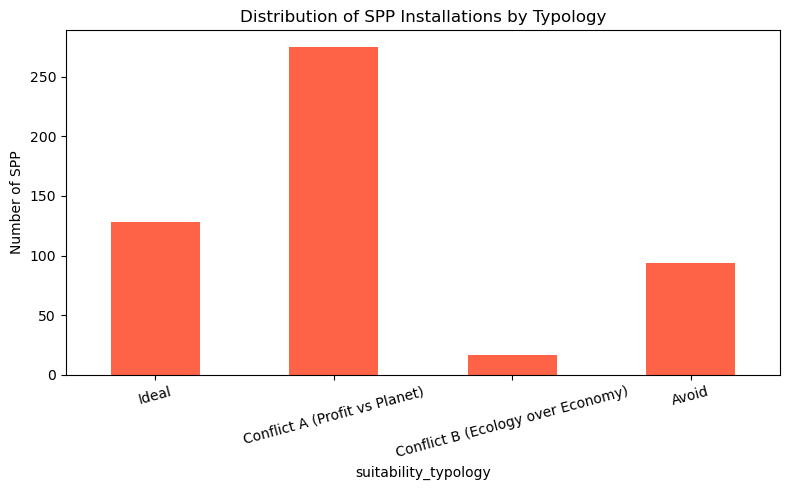

In [30]:
# Count SPP presence per typology
spp_by_typo = merged_data.groupby('suitability_typology')['SPP_presence_techno'].sum().reindex(['Ideal', 'Conflict A (Profit vs Planet)', 'Conflict B (Ecology over Economy)', 'Avoid'])

plt.figure(figsize=(8, 5))
spp_by_typo.plot(kind='bar', color='tomato')
plt.ylabel('Number of SPP')
plt.title('Distribution of SPP Installations by Typology')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [42]:
power_plants = gpd.read_file ("/Users/eliviau/Documents/hex2vec/power_plants_hokkaido.geojson")

In [43]:
power_plants.head()

,ID,prefecture,latitude,longitude,power,geometry
0,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654)
1,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094)
2,106,Hokkaido,43.198158,140.775253,1.98016,POINT (140.77525 43.19816)
3,111,Hokkaido,42.948497,141.814784,1.20400,POINT (141.81478 42.9485)
4,112,Hokkaido,43.050081,141.804632,0.92400,POINT (141.80463 43.05008)


In [16]:
socio_env.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,is_protected,SPP_presence,geometry
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,0,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973..."
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,0,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545..."
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,0,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688..."
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,1,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142..."
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,0,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914..."


In [9]:

socio_env = socio_env.set_index("region_id")  

In [67]:
merged_data.head()

,region_id,biodiversity_score,landcover_score_socio,sediment_score,ahp_total_score_socio,is_protected,SPP_presence_socio,geometry_socio,slope_score,aspect_score,ahp_solar_score,landcover_score_techno,road_score,ahp_total_score_techno,SPP_presence_techno,geometry_techno
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,0,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",9.333333,1.812500,9.000000,4.545455,1.608776,4.806089,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973..."
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,0,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0.000000,0.500000,NaN,4.000000,0.000000,NaN,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545..."
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,0,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",6.000000,5.230769,8.846154,8.533333,0.000000,5.427077,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688..."
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,1,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",8.166667,1.066667,9.000000,4.600000,0.000000,4.280000,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142..."
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,0,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",9.272727,0.000000,5.000000,5.380952,1.105167,4.087723,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914..."


In [60]:

import folium

# Define custom colors for each category
category_colors = {
    "Ideal": "#2ca25f",  # Green
    "Avoid": "#f03b20",  # Red
    "Conflict A (Economy over Ecology)": "#feb24c",  # Orange
    "Conflict B (Ecology over Economy)": "#3182bd",  # Blue
}

# Create base map centered on your data (just once)
m = folium.Map(zoom_start=7, tiles='cartodbpositron')

# Define style function for polygons
def style_function(feature):
    typology = feature['properties']['suitability_typology']
    return {
        'fillColor': category_colors.get(typology, 'gray'),
        'color': 'black',
        'weight': 0.3,
        'fillOpacity': 0.75
    }

# Add polygons
folium.GeoJson(
    merged_data,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['suitability_typology'], aliases=['Type:']),
).add_to(m)

# Optional: Add custom legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; height: 130px;
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white; padding: 10px;">
<b>Suitability Typology</b><br>
<span style="background-color:#2ca25f;">&nbsp;&nbsp;&nbsp;</span> Ideal<br>
<span style="background-color:#f03b20;">&nbsp;&nbsp;&nbsp;</span> Avoid<br>
<span style="background-color:#feb24c;">&nbsp;&nbsp;&nbsp;</span> Conflict A<br>
<span style="background-color:#3182bd;">&nbsp;&nbsp;&nbsp;</span> Conflict B<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Show map
m


ValueError: Cannot render objects with any missing geometries:              region_id  biodiversity_score  landcover_score_socio  \
0      872e1bca5ffffff                 9.0               1.515152   
1      872e8db45ffffff                 2.0               0.000000   
2      872eac323ffffff                 3.0               5.133333   
3      872e1ea0affffff                 6.0               1.400000   
4      872e192ecffffff                 4.0               2.309524   
...                ...                 ...                    ...   
31783  872eadce6ffffff                 3.0               1.581395   
31784  872ef4346ffffff                 NaN               0.000000   
31785  872ea97a6ffffff                 9.0               4.041667   
31786  872e1e401ffffff                 4.5               1.750000   
31787  872ef478dffffff                 NaN               0.000000   

       sediment_score  ahp_total_score_socio  is_protected  \
0                10.0               5.407576  

In [10]:
import geopandas as gpd
import folium
from srai.plotting import plot_numeric_data

# ----------- DATA PREP -----------

# Step 1: Classify regions as high/low suitability
LOW_SUIT_THRESHOLD = 5
socio_env["suitability_class"] = socio_env["ahp_total_score"].apply(
    lambda x: "low" if x < LOW_SUIT_THRESHOLD else "high"
)

# Step 2: Ensure same CRS
power_plants = power_plants.to_crs(socio_env.crs)

# Step 3: Spatial join to find power plants in low suitability zones
conflict_se = gpd.sjoin(
    power_plants,
    socio_env[["geometry", "ahp_total_score", "suitability_class", "SPP_presence"]],
    how="inner",
    predicate="within"
)
conflict_se = conflict_se[conflict_se["suitability_class"] == "low"]

# ----------- CATEGORIZE SIZE -----------

# Step 4: Create size category for power plants
def classify_size(power):
    if power < 10:
        return "small"
    elif 10 <= power < 50:
        return "medium"
    else:
        return "large"

power_plants["size_category"] = power_plants["power"].apply(classify_size)
size_mapping = {"small": 6, "medium": 12, "large": 20}
power_plants["radius_px"] = power_plants["size_category"].map(size_mapping)

# ----------- CREATE BASE MAP -----------

# Step 5: Create folium base map from AHP scores
m = plot_numeric_data(socio_env, "ahp_total_score", colormap="RdYlGn", opacity=0.6)



# ----------- ADD BLACK POWER PLANTS -----------

for _, row in power_plants.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row["radius_px"],
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(tooltip_text),
    ).add_to(m)

# ----------- ADD RED CONFLICT ZONES -----------

for _, row in conflict_se.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    radius_val = size_mapping[classify_size(row["power"])]
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius_val,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        tooltip=folium.Tooltip(tooltip_text),
    ).add_to(m)

# ----------- SAVE FINAL MAP -----------

m.save("conflictenv.html")



In [52]:
merged_data.head()

,region_id,biodiversity_score,landcover_score_socio,sediment_score,ahp_total_score_socio,is_protected,SPP_presence_socio,geometry,slope_score,aspect_score,ahp_solar_score,landcover_score_techno,road_score,ahp_total_score_techno,SPP_presence_techno,suitability_typology
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,0,0,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",9.333333,1.812500,9.000000,4.545455,1.608776,4.806089,0,Conflict B (Ecology over Economy)
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,0,0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0.000000,0.500000,NaN,4.000000,0.000000,NaN,0,Avoid
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,0,0,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",6.000000,5.230769,8.846154,8.533333,0.000000,5.427077,0,Ideal
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,1,0,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",8.166667,1.066667,9.000000,4.600000,0.000000,4.280000,0,Avoid
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,0,1,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",9.272727,0.000000,5.000000,5.380952,1.105167,4.087723,1,Avoid


In [54]:
#keep only the columns : region_id, geometry, suitability_typology
merged_data = merged_data[['region_id', 'geometry', 'suitability_typology']]

In [59]:
import geopandas as gpd
import folium
from folium import features
from shapely.geometry import Polygon

# Define a color dictionary for each category
category_colors = {
    "Ideal": "#2ca25f",  # Green
    "Avoid": "#f03b20",  # Red
    "Conflict A (Economy over Ecology)": "#feb24c",  # Orange
    "Conflict B (Ecology over Economy)": "#3182bd",  # Blue
    # Add any additional categories if needed
}

# Create a folium map centered on the mean coordinates of the dataset
center = merged_data.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=7, tiles='cartodbpositron')

# Function to style each hexagon based on the 'suitability_typology'
def style_function(feature):
    typology = feature['properties']['suitability_typology']
    color = category_colors.get(typology, "gray")
    return {
        'fillColor': color,
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7
    }

# Convert to GeoJSON for folium
folium.GeoJson(
    merged_data,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['suitability_typology'], aliases=['Type:']),
).add_to(m)

# Add a legend manually
legend_html = """
<div style="position: fixed; 
     bottom: 30px; left: 30px; width: 250px; height: 130px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color: white; padding: 10px;">
<b>Suitability Typology</b><br>
<span style="background-color:#2ca25f;color:white;">&nbsp;&nbsp;&nbsp;</span> Ideal<br>
<span style="background-color:#f03b20;color:white;">&nbsp;&nbsp;&nbsp;</span> Avoid<br>
<span style="background-color:#feb24c;color:white;">&nbsp;&nbsp;&nbsp;</span> Conflict A<br>
<span style="background-color:#3182bd;color:white;">&nbsp;&nbsp;&nbsp;</span> Conflict B<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save or display the map
m.save("suitability_typology_map.html")
m


AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column ('geometry') is not present. 
There are columns with geometry data type (['geometry_socio', 'geometry_techno']), and you can either set one as the active geometry with df.set_geometry("name") or access the column as a GeoSeries (df["name"]) and call the method directly on it.

In [55]:
merged_data.head()

,region_id,geometry,suitability_typology
0,872e1bca5ffffff,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",Conflict B (Ecology over Economy)
1,872e8db45ffffff,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",Avoid
2,872eac323ffffff,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",Ideal
3,872e1ea0affffff,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",Avoid
4,872e192ecffffff,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",Avoid


In [53]:
import folium
from folium import Tooltip
import geopandas as gpd

# --------- STEP 1: Color palette for the 4 typologies ---------

typology_colors = {
    'Ideal': '#4CAF50',                                # Green
    'Avoid': '#90A4AE',                                # Grey-Blue
    'Conflict A (Profit vs Planet)': '#F44336',        # Red
    'Conflict B (Ecology over Economy)': '#FFC107'     # Amber
}

# --------- STEP 2: Create a folium base map ---------

center = merged_data.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=8, tiles='cartodbpositron')

# --------- STEP 3: Add hexagons colored by typology ---------

for _, row in merged_data.iterrows():
    color = typology_colors.get(row['suitability_typology'], 'gray')  # fallback color
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, color=color: {
            'fillColor': color,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.6
        },
        tooltip=Tooltip(f"{row['suitability_typology']}")
    ).add_to(m)

# --------- STEP 4: Save the map ---------

m.save("typology_conflict_map.html")


AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column ('geometry_techno') is not present. 
There are columns with geometry data type (['geometry']), and you can either set one as the active geometry with df.set_geometry("name") or access the column as a GeoSeries (df["name"]) and call the method directly on it.

In [51]:
#from merged_data, rename geometry_socio to geometry
merged_data = merged_data.rename(columns={'geometry_socio': 'geometry'})

#from merged_data remove column geometry_techno
merged_data = merged_data.drop(columns=['geometry_techno'])

In [ ]:
# Step 5: Create folium base map from AHP scores
m = plot_numeric_data(techno_econ, "ahp_total_score", colormap="RdYlGn", opacity=0.6)


In [47]:
import geopandas as gpd
import folium
from folium import Tooltip
import branca.colormap as cm

# ----------- STEP 1: Ensure CRS Alignment and Geometry -----------


# ----------- STEP 2: Define Colors for Typology -----------

typology_colors = {
    'Ideal': '#4CAF50',          # Green
    'Avoid': '#90A4AE',          # Grey-Blue
    'Conflict A (Profit vs Planet)': '#F44336',  # Red
    'Conflict B (Ecology over Economy)': '#FFC107'  # Yellow
}

# ----------- STEP 3: Create Base Folium Map -----------

# Use center of your dataset to center the map
center = merged_data.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=8, tiles='cartodbpositron')

# ----------- STEP 4: Add Colored Hexagons by Typology -----------

for _, row in merged_data.iterrows():
    color = typology_colors.get(row['suitability_typology'], 'gray')
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, color=color: {
            'fillColor': color,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.5
        },
        tooltip=row['suitability_typology']
    ).add_to(m)

# ----------- STEP 5: Add Black Power Plants with Size Scaling -----------

# Define size categories
def classify_size(power):
    if power < 10:
        return "small"
    elif 10 <= power < 50:
        return "medium"
    else:
        return "large"

size_mapping = {"small": 6, "medium": 12, "large": 20}

# Add categories and radii
power_plants["size_category"] = power_plants["power"].apply(classify_size)
power_plants["radius_px"] = power_plants["size_category"].map(size_mapping)

# Add power plants to map
for _, row in power_plants.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row["radius_px"],
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=Tooltip(tooltip_text),
    ).add_to(m)

# ----------- STEP 6: Save Map -----------

m.save("conflict_typology_map.html")


/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_69305/1808820689.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = merged_data.geometry.centroid.unary_union.centroid
/var/folders/ff/c4nl5pt146sgczby6pzfnt2h0000gn/T/ipykernel_69305/1808820689.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = merged_data.geometry.centroid.unary_union.centroid


KeyError: 'geometry'

In [9]:

techno_econ = techno_econ.set_index("region_id")  

## TECHNO ECONOMICAL

In [11]:
import geopandas as gpd
import folium
from srai.plotting import plot_numeric_data

# ----------- DATA PREP -----------

# Step 1: Classify regions as high/low suitability
LOW_SUIT_THRESHOLD = 5
techno_econ["suitability_class"] = techno_econ["ahp_total_score"].apply(
    lambda x: "low" if x < LOW_SUIT_THRESHOLD else "high"
)

# Step 2: Ensure same CRS
power_plants = power_plants.to_crs(techno_econ.crs)

# Step 3: Spatial join to find power plants in low suitability zones
conflict_se = gpd.sjoin(
    power_plants,
    techno_econ[["geometry", "ahp_total_score", "suitability_class", "SPP_presence"]],
    how="inner",
    predicate="within"
)
conflict_se = conflict_se[conflict_se["suitability_class"] == "low"]

# ----------- CATEGORIZE SIZE -----------

# Step 4: Create size category for power plants
def classify_size(power):
    if power < 10:
        return "small"
    elif 10 <= power < 50:
        return "medium"
    else:
        return "large"

power_plants["size_category"] = power_plants["power"].apply(classify_size)
size_mapping = {"small": 6, "medium": 12, "large": 20}
power_plants["radius_px"] = power_plants["size_category"].map(size_mapping)

# ----------- CREATE BASE MAP -----------

# Step 5: Create folium base map from AHP scores
m = plot_numeric_data(techno_econ, "ahp_total_score", colormap="RdYlGn", opacity=0.6)



# ----------- ADD BLACK POWER PLANTS -----------

for _, row in power_plants.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=row["radius_px"],
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(tooltip_text),
    ).add_to(m)

# ----------- ADD RED CONFLICT ZONES -----------

for _, row in conflict_se.iterrows():
    tooltip_text = f"ID: {row['ID']}<br>Power: {row['power']} MW"
    radius_val = size_mapping[classify_size(row["power"])]
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius_val,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        tooltip=folium.Tooltip(tooltip_text),
    ).add_to(m)

# ----------- SAVE FINAL MAP -----------

m.save("techno_econ_maptest.html")



## -------- ##


In [18]:
import folium

# Base map centered on Hokkaido
m = folium.Map(location=[43.0, 142.0], zoom_start=6, tiles="cartodbpositron")


In [19]:
#FIRST LAYER
import geopandas as gpd
from folium.features import GeoJsonTooltip
import branca.colormap as cm


# Palette
colormap = cm.linear.YlGnBu_09.scale(0, 10)

# Fonction de style robuste
def style_function(feature):
    val = feature["properties"].get("ahp_total_score")
    return {
        "fillColor": "#cccccc" if val is None else colormap(val),
        "color": "none",
        "weight": 0.3,
        "fillOpacity": 0.6,
    }

folium.GeoJson(
    techno_econ,
    name="Techno-Economic Suitability",
    style_function=style_function,
    tooltip=GeoJsonTooltip(fields=["region_id", "ahp_total_score"])
).add_to(m)



In [ ]:
#SECOND LAYER
colormap_socio = cm.linear.YlGnBu_09.scale(0, 10)
def style_socio(feature):
    val = feature["properties"].get("ahp_total_score")
    return {
        "fillColor": "#cccccc" if val is None else colormap_socio(val),
        "color": "none",
        "weight": 0.3,
        "fillOpacity": 0.6,
    }

folium.GeoJson(
    socio_env,
    name="Socio-Environmental Suitability",
    style_function=style_socio,
    tooltip=GeoJsonTooltip(fields=["region_id", "ahp_total_score"])
).add_to(m)

# Add legend
colormap_socio.caption = "AHP Total Score"
colormap_socio.add_to(m)



In [21]:

# Add layer control
folium.LayerControl().add_to(m)


In [22]:

# Save to HTML
m.save("interactive_map_hokkaido.html")


In [ ]:
import folium
import geopandas as gpd
from folium.features import GeoJsonTooltip
import branca.colormap as cm
from geopandas.tools import sjoin

# Base map centered on Hokkaido
m = folium.Map(location=[43.0, 142.0], zoom_start=6, tiles="cartodbpositron")

# ---------------------------- #
#        GLOBAL SETTINGS       #
# ---------------------------- #
THRESHOLD = 5  # Suitability threshold for conflict

# Harmonize CRS
power_plants = power_plants.to_crs(techno_econ.crs)

# ---------------------------- #
#          FIRST LAYER         #
#   Techno-Economic Suitability
# ---------------------------- #
colormap = cm.linear.YlGnBu_09.scale(0, 10)

def style_function(feature):
    val = feature["properties"].get("ahp_total_score")
    return {
        "fillColor": "#cccccc" if val is None else colormap(val),
        "color": "none",
        "weight": 0.3,
        "fillOpacity": 0.8,  # stronger color
    }

# Add techno layer
folium.GeoJson(
    techno_econ,
    name="Techno-Economic Suitability",
    style_function=style_function,
    tooltip=GeoJsonTooltip(fields=["region_id", "ahp_total_score"])
).add_to(m)

# Detect conflicts
low_techno = techno_econ[techno_econ["ahp_total_score"] < THRESHOLD]
conflict_techno = sjoin(power_plants, low_techno, predicate="within", how="inner")

# ---------------------------- #
#          SECOND LAYER        #
#  Socio-Environmental Suitability
# ---------------------------- #
colormap_socio = cm.linear.Greens_09.scale(0, 10)

def style_socio(feature):
    val = feature["properties"].get("ahp_total_score")
    return {
        "fillColor": "#cccccc" if val is None else colormap_socio(val),
        "color": "none",
        "weight": 0.3,
        "fillOpacity": 0.8,
    }

# Add socio layer
folium.GeoJson(
    socio_env,
    name="Socio-Environmental Suitability",
    style_function=style_socio,
    tooltip=GeoJsonTooltip(fields=["region_id", "ahp_total_score"])
).add_to(m)

# Detect conflicts
low_socio = socio_env[socio_env["ahp_total_score"] < THRESHOLD]
conflict_socio = sjoin(power_plants, low_socio, predicate="within", how="inner")

# ---------------------------- #
#        ADD POWER PLANTS      #
# ---------------------------- #

# Add ALL SPP in black
for _, row in power_plants.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="black",
        fill=True,
        fill_opacity=1,
    ).add_to(m)

# Add techno-conflict SPP in red
for _, row in conflict_techno.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=1,
    ).add_to(m)

# Add socio-conflict SPP in orange
for _, row in conflict_socio.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color="orange",
        fill=True,
        fill_color="orange",
        fill_opacity=1,
    ).add_to(m)

# ---------------------------- #
#         LEGENDS & LAYERS     #
# ---------------------------- #
colormap.caption = "AHP Total Score (Techno-Economic)"
colormap.add_to(m)

colormap_socio.caption = "AHP Total Score (Socio-Environmental)"
colormap_socio.add_to(m)

folium.LayerControl().add_to(m)

# ---------------------------- #
#            EXPORT            #
# ---------------------------- #
m.save("interactive_map_hokkaido.html")
